# Loading Libraries

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.model_selection import GridSearchCV

# Loading Data

In [ ]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import PROCESSED_DATA_DIR

import pandas as pd

# Load the data
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test_processed.csv")

# Feature and Target Split

In [5]:
X_train = train_df.drop(columns="Diabetes_binary")
y_train = train_df["Diabetes_binary"]

X_test = test_df.drop(columns="Diabetes_binary")
y_test = test_df["Diabetes_binary"]

# Function to evaluate model

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name=''):
    # Train predictions
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds, average='binary')  # or 'macro' for multi-class
    train_cf = confusion_matrix(y_train, train_preds, normalize='true')
    
    # Test predictions
    test_preds = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds, average='binary')
    test_cf = confusion_matrix(y_test, test_preds, normalize='true')
    
    # Print accuracy and recall
    print(f"{name} Accuracy:")
    print(f"  Train: {train_accuracy * 100:.2f}%")
    print(f"  Test : {test_accuracy * 100:.2f}%")
    print(f"{name} Recall:")
    print(f"  Train: {train_recall * 100:.2f}%")
    print(f"  Test : {test_recall * 100:.2f}%")

    # Print classification report (includes recall too)
    print(f"\n{name} Classification Report (Test):")
    print(classification_report(y_test, test_preds))

    # Plot confusion matrices
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(train_cf, annot=True, ax=axs[0], cmap='Blues')
    axs[0].set_title(f"{name} - Train Confusion Matrix")
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    sns.heatmap(test_cf, annot=True, ax=axs[1], cmap='Greens')
    axs[1].set_title(f"{name} - Test Confusion Matrix")
    axs[1].set_xlabel('Predicted')
    axs[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
    

# Naive Bayes

### Gaussian Naive Bayes

GaussianNB Accuracy:
  Train: 72.24%
  Test : 73.05%
GaussianNB Recall:
  Train: 74.44%
  Test : 74.51%

GaussianNB Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.73      0.72      0.72      6723
         1.0       0.73      0.75      0.74      7089

    accuracy                           0.73     13812
   macro avg       0.73      0.73      0.73     13812
weighted avg       0.73      0.73      0.73     13812



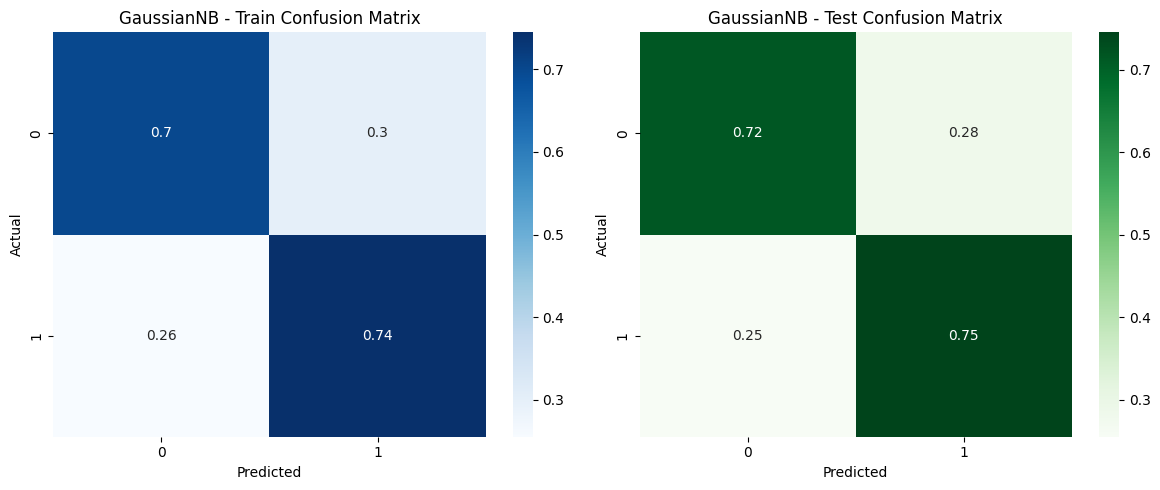

In [8]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
evaluate_model(gnb, X_train, y_train, X_test, y_test, name='GaussianNB')

### Gaussian Naivebayes Tuned

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best Parameters for GaussianNB:
{'var_smoothing': 1e-12}
Tuned GaussianNB Accuracy:
  Train: 72.24%
  Test : 73.05%
Tuned GaussianNB Recall:
  Train: 74.44%
  Test : 74.51%

Tuned GaussianNB Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.73      0.72      0.72      6723
         1.0       0.73      0.75      0.74      7089

    accuracy                           0.73     13812
   macro avg       0.73      0.73      0.73     13812
weighted avg       0.73      0.73      0.73     13812



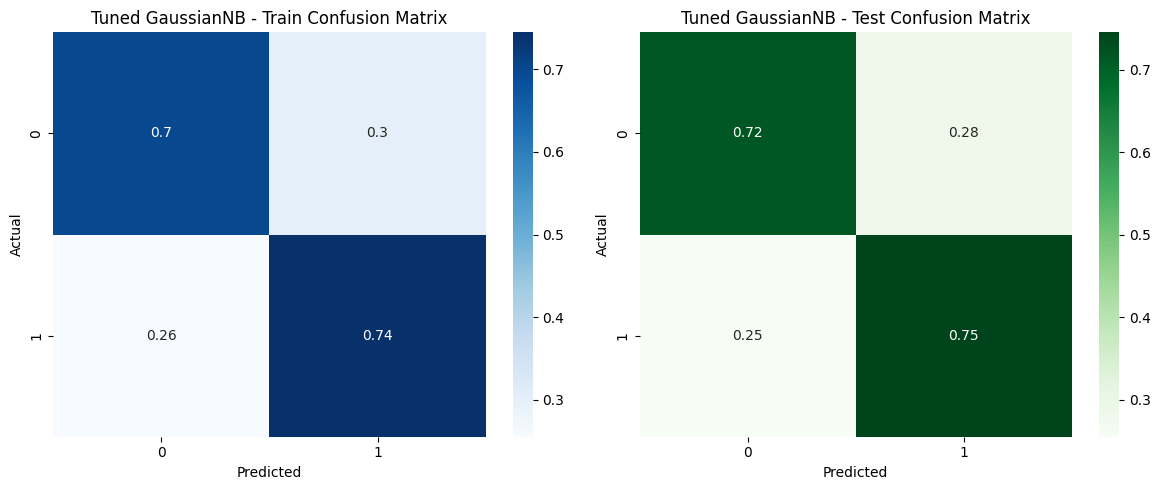

In [10]:
param_grid_gnb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

gnb = GaussianNB()

grid_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_gnb.fit(X_train, y_train)

print("Best Parameters for GaussianNB:")
print(grid_gnb.best_params_)

# Evaluate best estimator
evaluate_model(grid_gnb.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned GaussianNB")

# Ensemble

### GradientBoostingClassifier

Gradient Boosting Accuracy:
  Train: 74.66%
  Test : 75.46%
Gradient Boosting Recall:
  Train: 79.56%
  Test : 79.52%

Gradient Boosting Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      6723
         1.0       0.74      0.80      0.77      7089

    accuracy                           0.75     13812
   macro avg       0.76      0.75      0.75     13812
weighted avg       0.76      0.75      0.75     13812



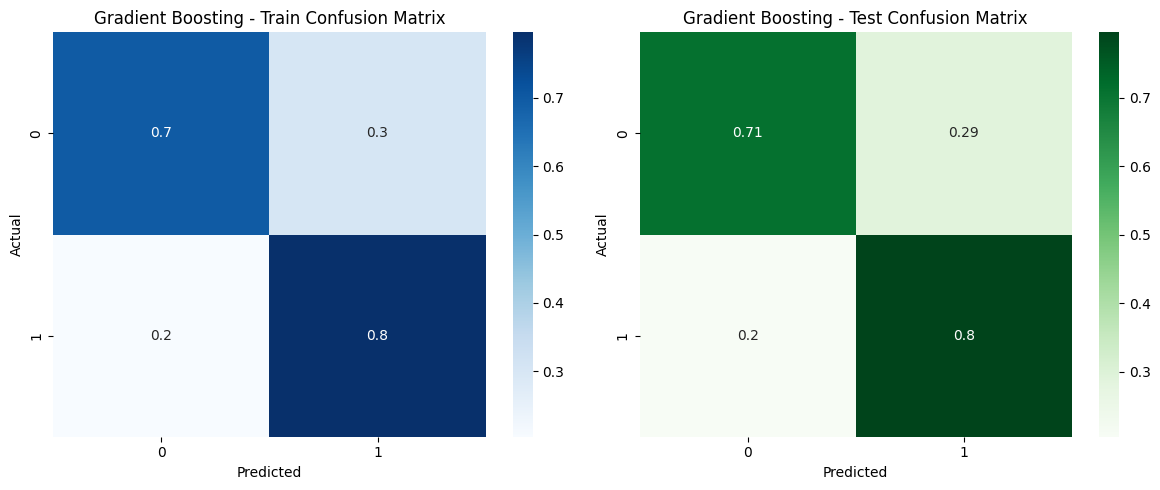

In [11]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

evaluate_model(gb, X_train, y_train, X_test, y_test, name="Gradient Boosting")

### GradientBoostingClassifier Tuned

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters for GradientBoostingClassifier:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Tuned Gradient Boosting Accuracy:
  Train: 75.03%
  Test : 75.56%
Tuned Gradient Boosting Recall:
  Train: 80.11%
  Test : 80.08%

Tuned Gradient Boosting Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      6723
         1.0       0.74      0.80      0.77      7089

    accuracy                           0.76     13812
   macro avg       0.76      0.75      0.75     13812
weighted avg       0.76      0.76      0.75     13812



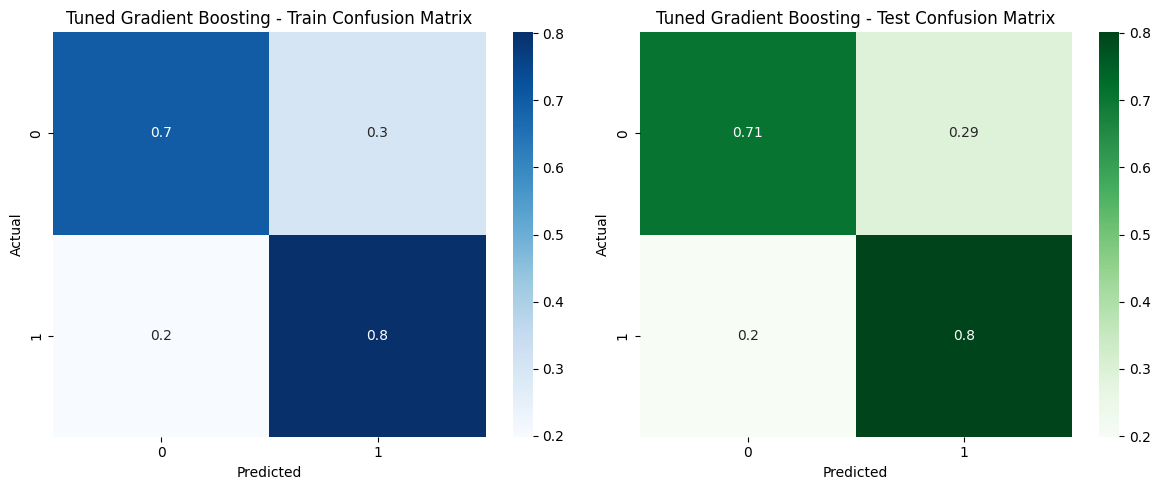

In [12]:
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [1.0, 0.8]
}

gb = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(gb, param_grid_gb, cv=3, scoring='recall', n_jobs=-1, verbose=1)
grid_gb.fit(X_train, y_train)

print("Best Parameters for GradientBoostingClassifier:")
print(grid_gb.best_params_)

evaluate_model(grid_gb.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned Gradient Boosting")

### AdaBoostClassifier

AdaBoost Classifier Accuracy:
  Train: 74.08%
  Test : 75.14%
AdaBoost Classifier Recall:
  Train: 76.65%
  Test : 77.13%

AdaBoost Classifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      6723
         1.0       0.75      0.77      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



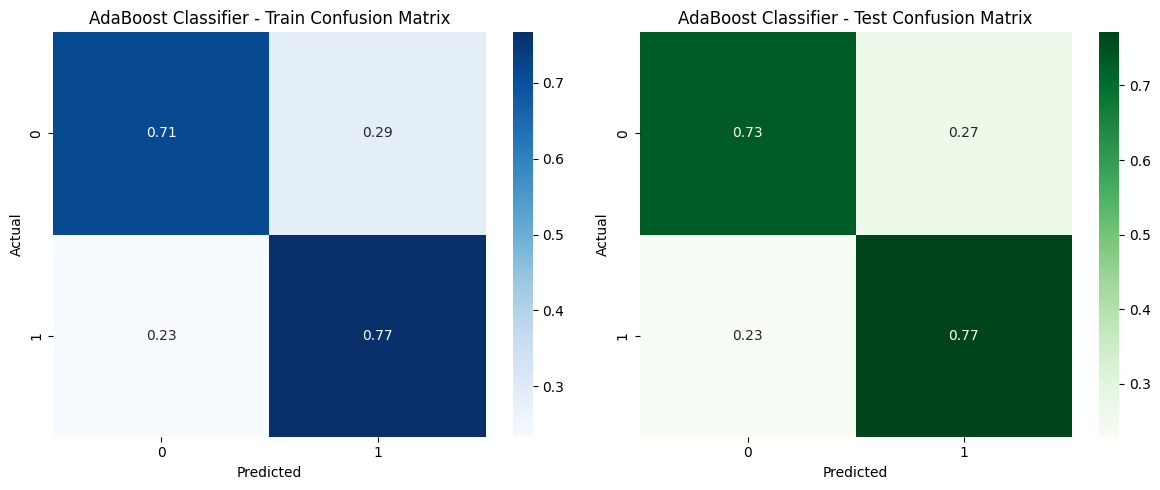

In [13]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada.fit(X_train, y_train)

evaluate_model(ada, X_train, y_train, X_test, y_test, name="AdaBoost Classifier")

### ADABoostClassifier Tuned

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters for AdaBoostClassifier:
{'learning_rate': 0.5, 'n_estimators': 100}
Tuned AdaBoost Classifier Accuracy:
  Train: 74.11%
  Test : 75.35%
Tuned AdaBoost Classifier Recall:
  Train: 77.60%
  Test : 78.21%

Tuned AdaBoost Classifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74      6723
         1.0       0.75      0.78      0.77      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



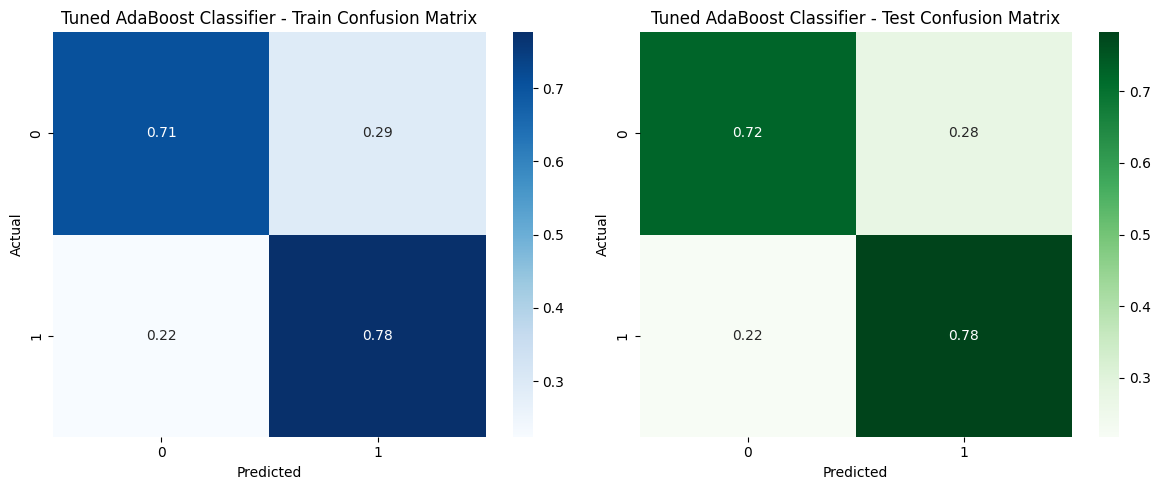

In [14]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5]
}

ada = AdaBoostClassifier(random_state=42)

grid_ada = GridSearchCV(ada, param_grid_ada, cv=3, scoring='recall', n_jobs=-1, verbose=1)
grid_ada.fit(X_train, y_train)

print("Best Parameters for AdaBoostClassifier:")
print(grid_ada.best_params_)

evaluate_model(grid_ada.best_estimator_, X_train, y_train, X_test, y_test, name="Tuned AdaBoost Classifier")

### VotingClassifier

Voting Classifier Accuracy:
  Train: 75.50%
  Test : 75.25%
Voting Classifier Recall:
  Train: 77.55%
  Test : 76.82%

Voting Classifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.75      0.74      0.74      6723
         1.0       0.75      0.77      0.76      7089

    accuracy                           0.75     13812
   macro avg       0.75      0.75      0.75     13812
weighted avg       0.75      0.75      0.75     13812



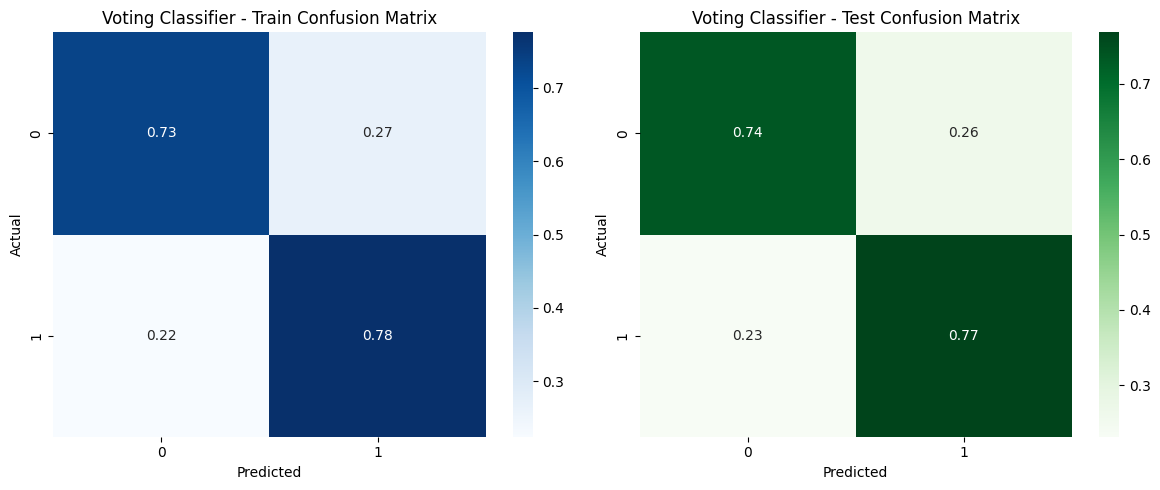

In [15]:
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(max_depth=20, min_samples_leaf=6, min_samples_split=15, n_estimators=30, random_state=42)),
        ('gnb', GaussianNB(var_smoothing=1e-12)),
        ('gb', GradientBoostingClassifier(learning_rate= 0.1, max_depth= 3, n_estimators=100, subsample=1.0, random_state=42)),
        ('ada', AdaBoostClassifier(learning_rate=1.5, n_estimators=100, random_state=42))
    ],
    voting='hard'
)
voting.fit(X_train, y_train)

evaluate_model(voting, X_train, y_train, X_test, y_test, name="Voting Classifier")

### Stacking Classifier

Stacking Classifier Accuracy:
  Train: 75.14%
  Test : 75.52%
Stacking Classifier Recall:
  Train: 79.19%
  Test : 78.94%

Stacking Classifier Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74      6723
         1.0       0.75      0.79      0.77      7089

    accuracy                           0.76     13812
   macro avg       0.76      0.75      0.75     13812
weighted avg       0.76      0.76      0.75     13812



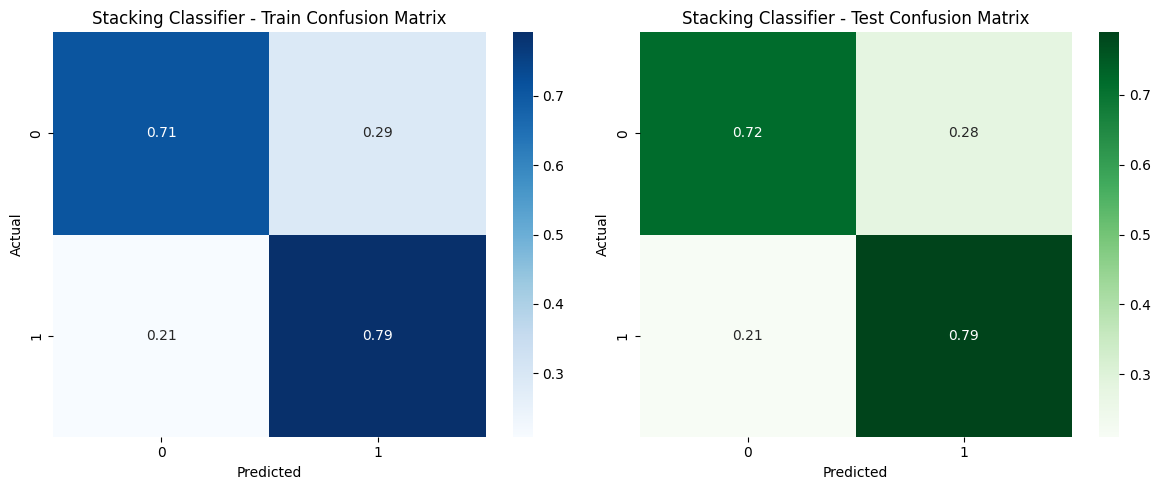

In [16]:
stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(max_depth=20, min_samples_leaf=6, min_samples_split=15, n_estimators=30, random_state=42)),
        ('gnb', GaussianNB(var_smoothing=1e-12)),
        ('gb', GradientBoostingClassifier(learning_rate= 0.1, max_depth= 3, n_estimators=100, subsample=1.0, random_state=42)),
        ('ada', AdaBoostClassifier(learning_rate=1.5, n_estimators=100, random_state=42))
    ],
    final_estimator=LogisticRegression()
)
stacking.fit(X_train, y_train)

evaluate_model(stacking, X_train, y_train, X_test, y_test, name="Stacking Classifier")

# Evaluation

| Models | Training Recall | Test Recall|
|--------|-------------------|--------------|
|GaussianNB|74.44%|74.51%|
|GaussianNB (Tuned)|74.44%|74.51%|
|GradientBoostingClassifier|79.56%|79.52%|
|GradientBoostingClassifier (Tuned)|80.11%|80.08%|
|AdaBoostClassifier|76.65%|77.13%|
|AdaBoostClassifier (Tuned)|77.60%|78.21%|
|VotingClassifier|77.55%|76.82%|
|StackingClassifier|79.19%|78.94%|